In [26]:
from misc import *
import constant

In [27]:
# upto 5 long track candidates isMuon
LTRACK5_HIGH_MASS_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/LeadLead_dimuon_HighMass_all.root"
DEFAULT_TREE_NAME = "dimuonTuple/DecayTree"

df = load_root(LTRACK5_HIGH_MASS_FILE_PATH, DEFAULT_TREE_NAME)
# df = df[df["Kplus_isMuon"] == False]
# df = df[(constant.JPSI_MASS-50 <= df["J_psi_1S_M"]) & (df["J_psi_1S_M"] <= constant.JPSI_MASS+50)]



Histogram not saved to file
Histogram not saved to file


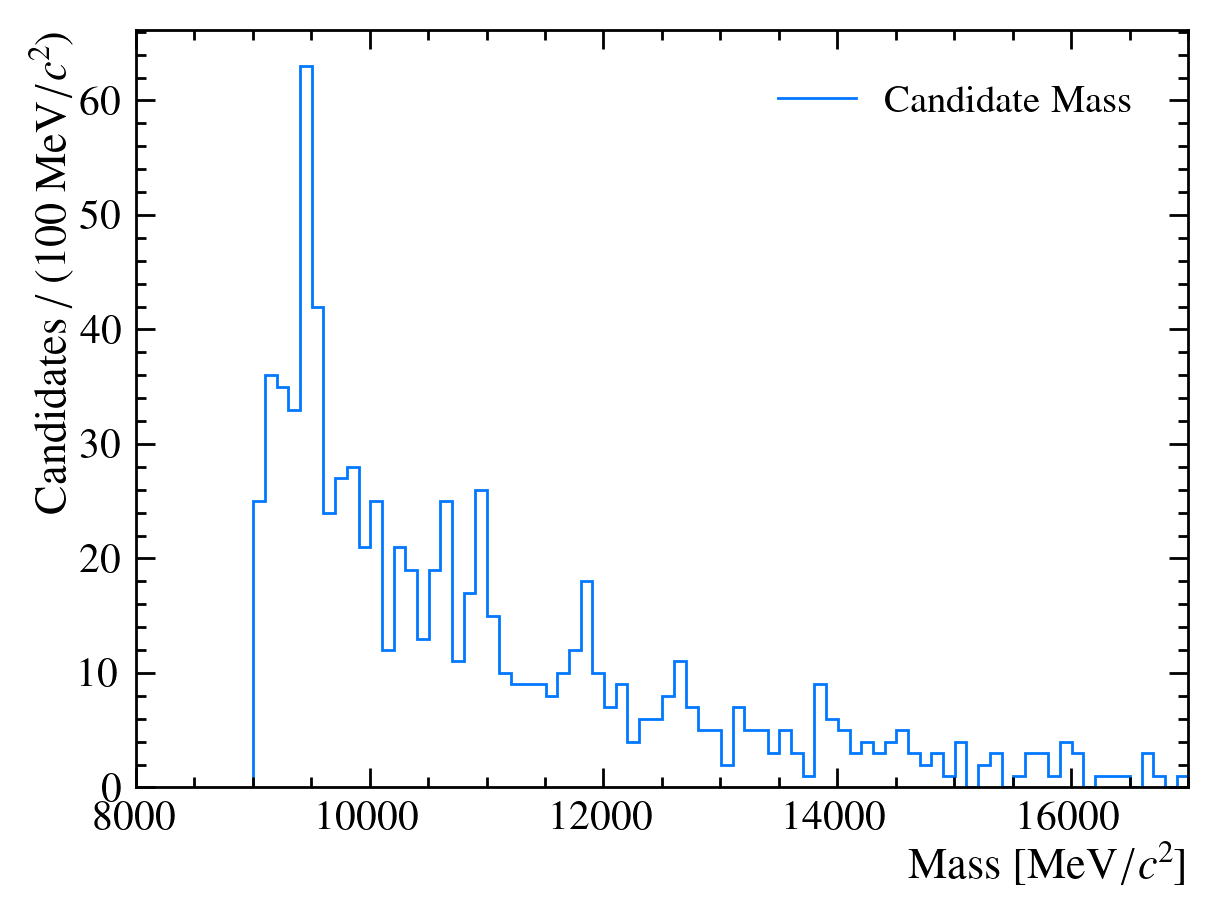

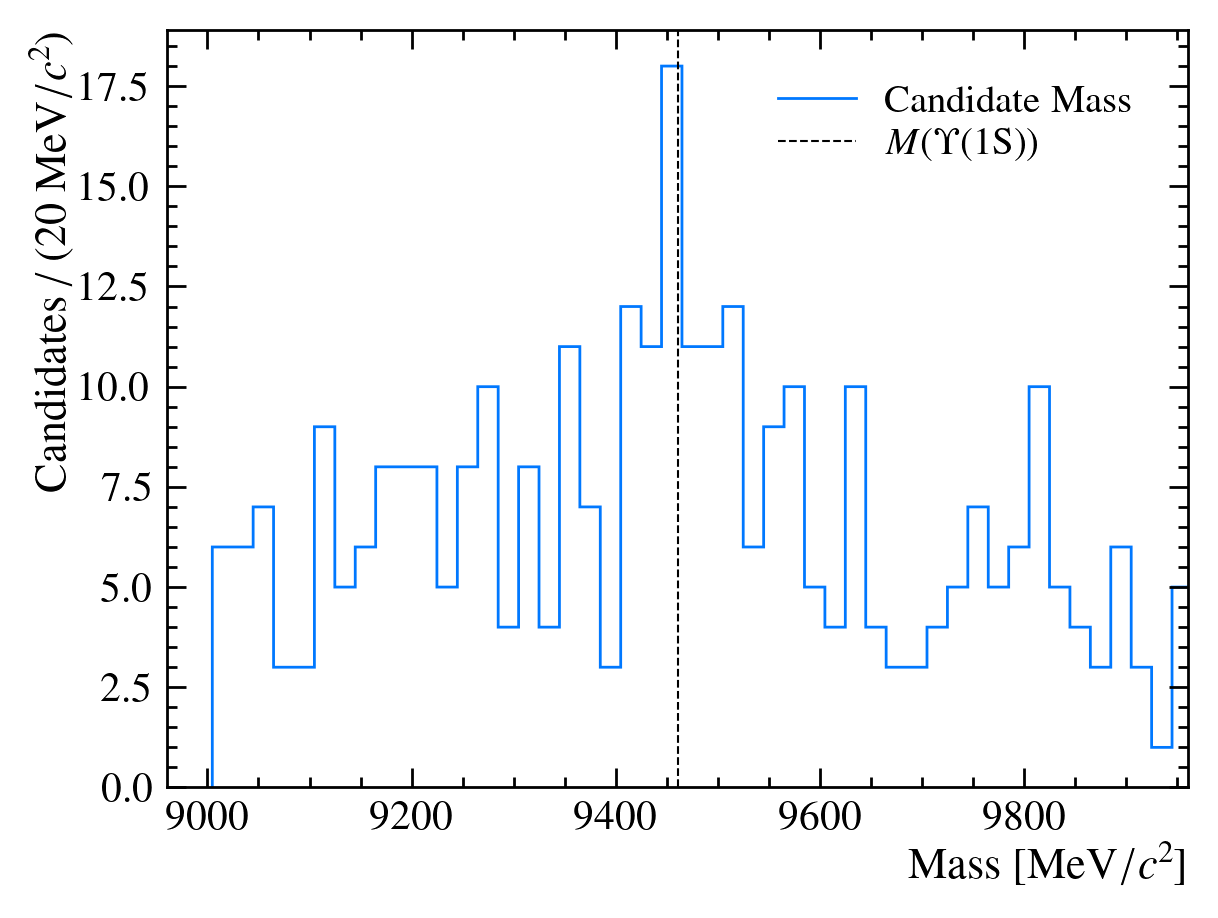

In [28]:
df = df[df["muplus_isMuon"] == True]
df = df[df["muminus_isMuon"] == True]

fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"], "Candidate Mass", bins=100)],
    False,
    xlim=[8000, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)

def add_upsilon(ax, xS, scale=1, **kwargs):
    for i in xS:
        mass = eval(f"constant.UPSILON_{i}S_MASS")
        label = r"$M(\Upsilon\mathrm{(" + f"{i}" + r"S)})$"
        ax.axvline(mass*scale, color="k", linewidth=1.5, label=label, ls="--", **kwargs)

ax.legend()

fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"], "Candidate Mass", bins=20)],
    False,
    xlim=[constant.UPSILON_1S_MASS - 500, constant.UPSILON_1S_MASS + 500],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)

ax.axvline(constant.UPSILON_1S_MASS, color="k", linewidth=1.5, label=r"$M(\Upsilon\mathrm{(1S)})$", ls="--")

ax.legend()

Histogram not saved to file


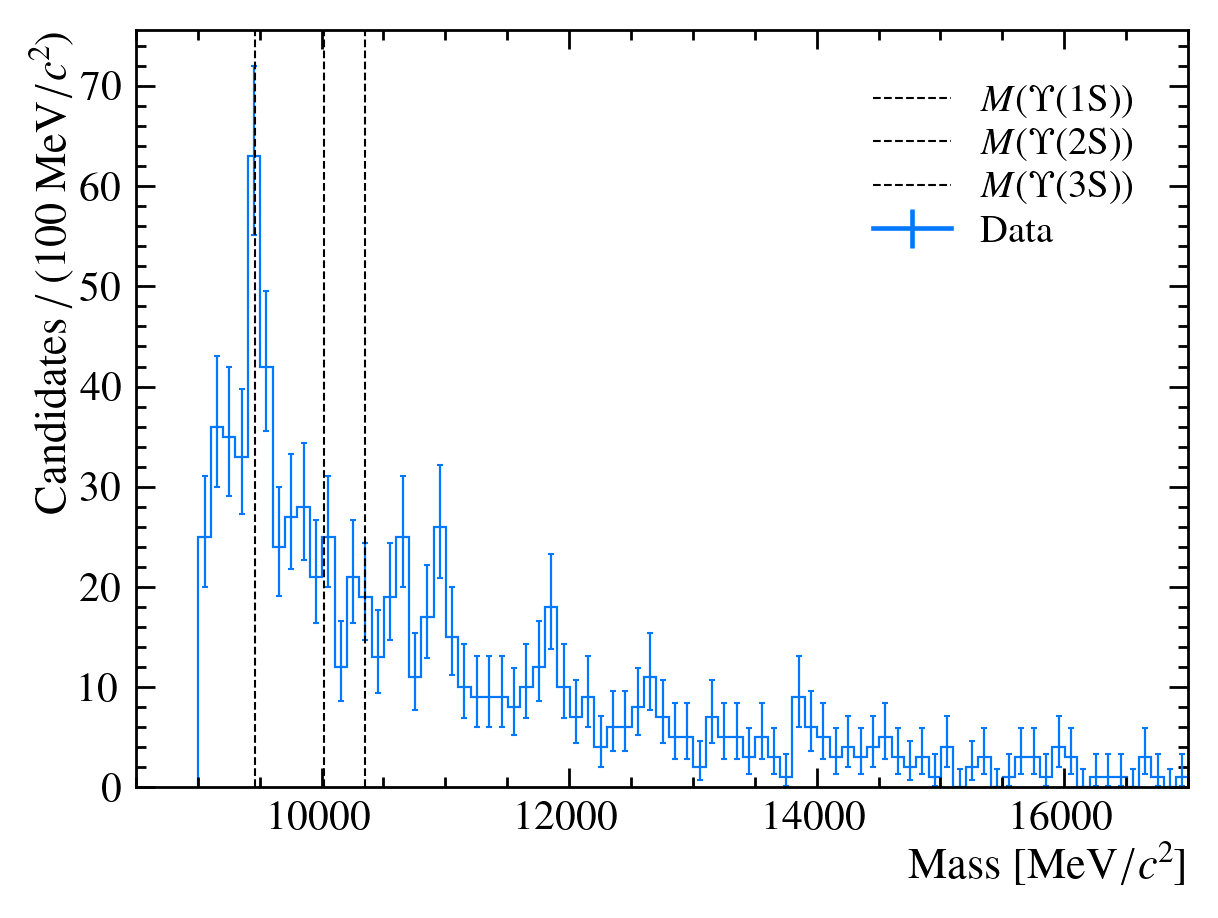

In [29]:
cut_df = df[df["nLongTracks"] == 2]
fig, ax = histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"], "Data", bins=100, error=True, lw=1.6),
    #  HistogramPlot(cut_df["J_psi_1S_M"], "nLongTracks = 2", bins=100)
     ],
    False,
    xlim=[8500, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass"
)
add_upsilon(ax, range(1,4))
ax.legend()

fig.savefig("figures/Report/Upsilon_mass.svg")

Histogram not saved to file


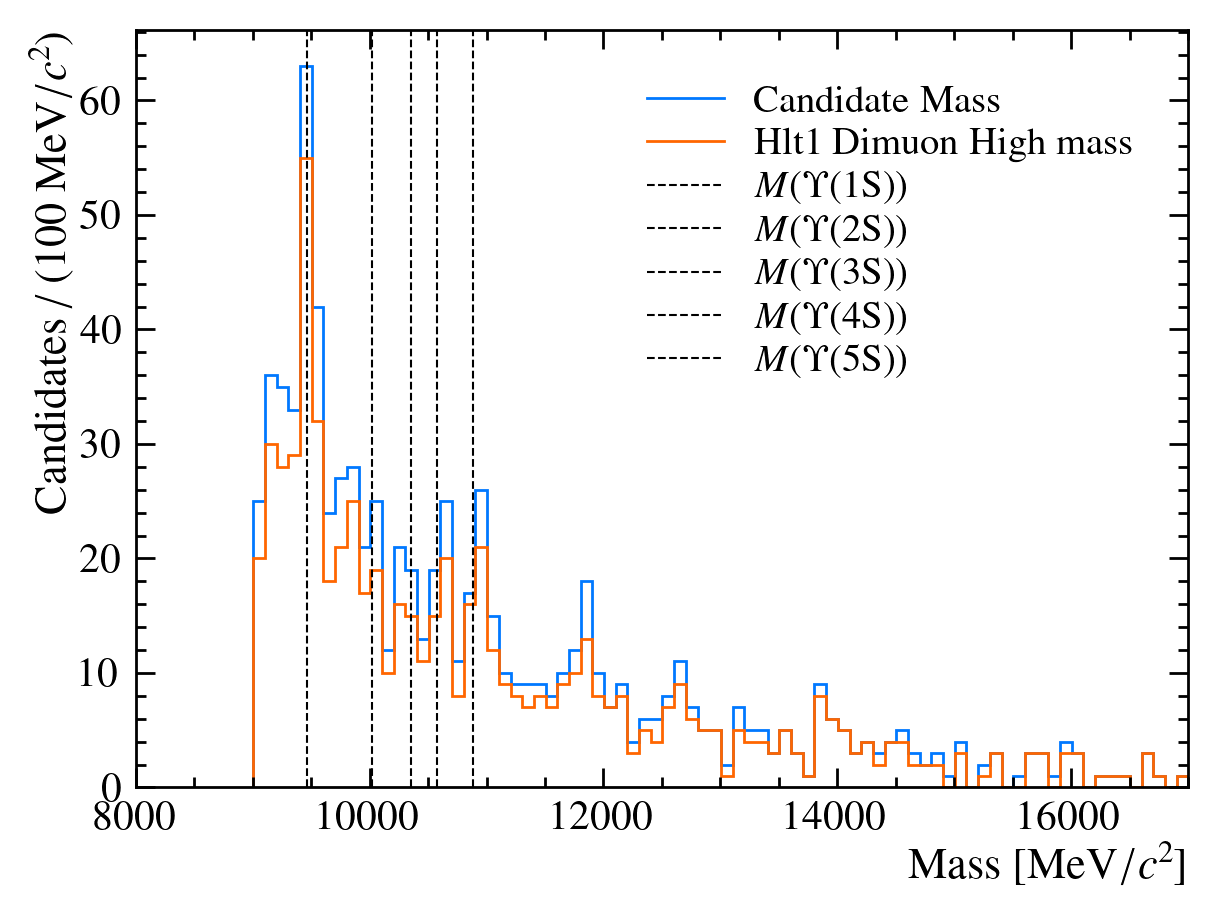

In [30]:
cut_df = df[df["Hlt1DiMuonHighMassDecision"] == True]

fig, ax = histogram_fig(
    [
        HistogramPlot(df["J_psi_1S_M"], "Candidate Mass", bins=100),
        HistogramPlot(cut_df["J_psi_1S_M"], "Hlt1 Dimuon High mass", bins=100),
    ],
    False,
    xlim=[8000, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass",
)
add_upsilon(ax, range(1,6))
ax.legend()

Histogram not saved to file


<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1292178/3016550173.py:6: SyntaxWarning: invalid escape sequence '\c'
  HistogramPlot(endvtx_chi2_df["J_psi_1S_M"], "$\chi^2 < 1$", bins=100),


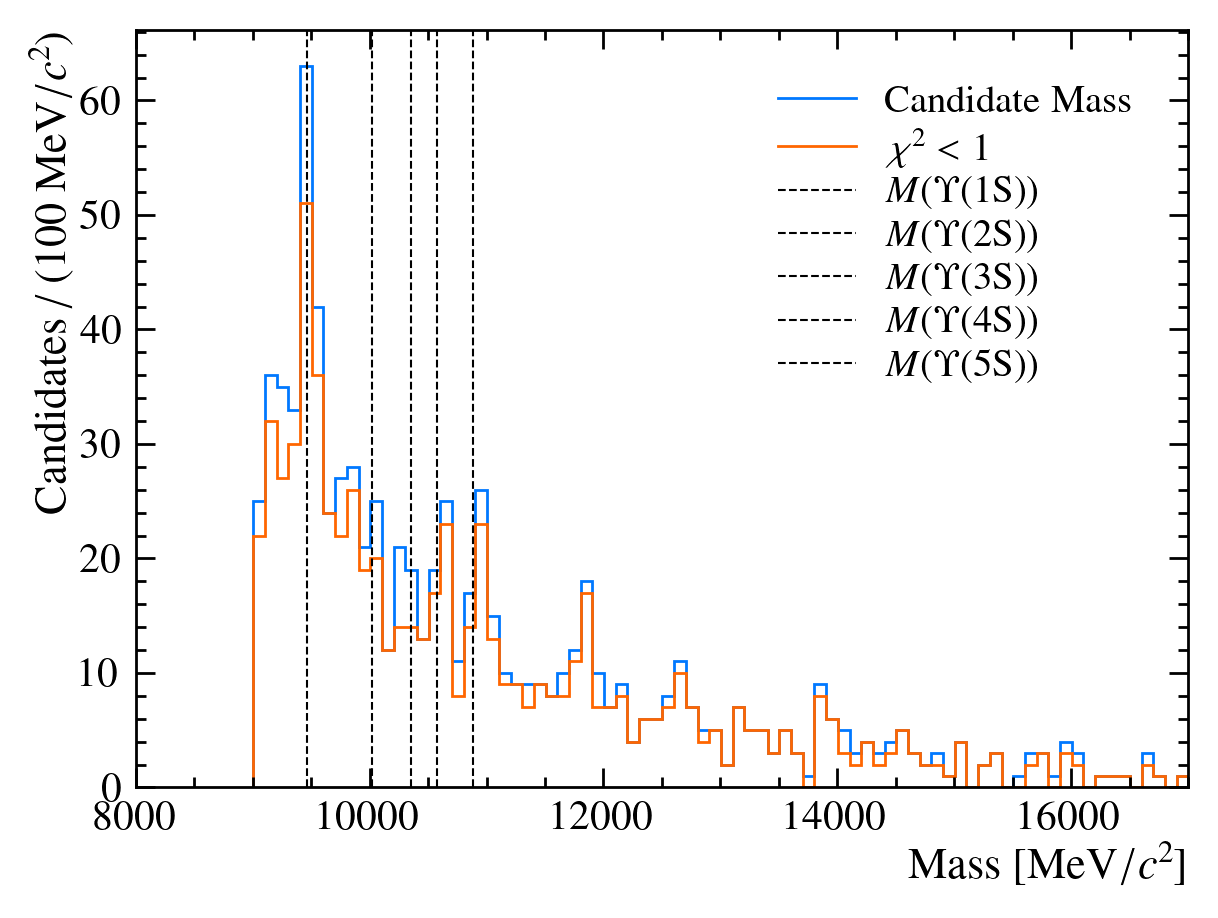

In [31]:
endvtx_chi2_df = df[df["J_psi_1S_ENDVERTEX_CHI2"] < 3]

fig, ax = histogram_fig(
    [
        HistogramPlot(df["J_psi_1S_M"], "Candidate Mass", bins=100),
        HistogramPlot(endvtx_chi2_df["J_psi_1S_M"], "$\chi^2 < 1$", bins=100),
    ],
    False,
    xlim=[8000, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass",
)
add_upsilon(ax, range(1,6))

ax.legend()

Histogram not saved to file


/software/ai21208/Code/misc.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


(<Figure size 1200x900 with 1 Axes>, <Axes: ylabel='Candidates / 0.328'>)

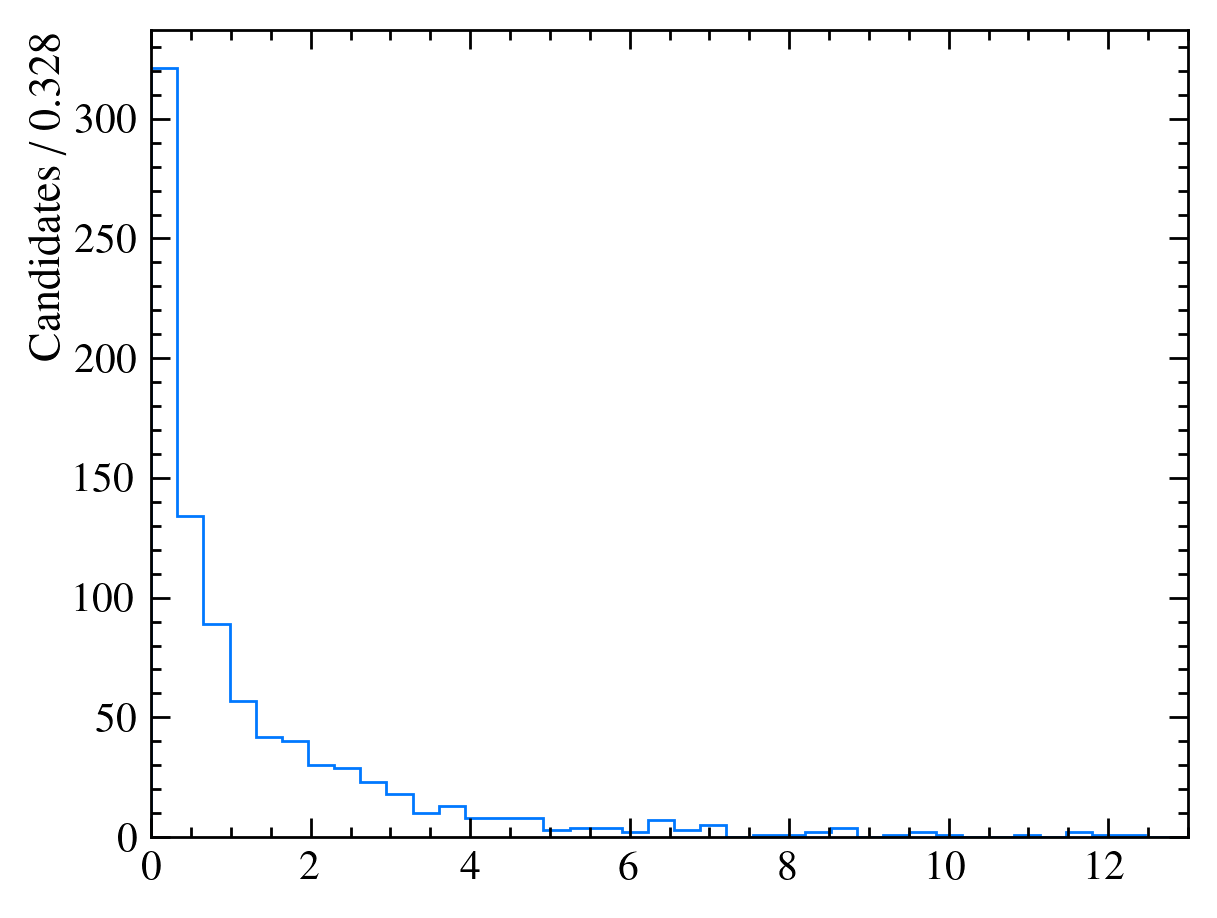

In [32]:
histogram_fig(
    [HistogramPlot(df["J_psi_1S_ENDVERTEX_CHI2"], "")],
    False,
    xlim=[0,13]
)

Histogram not saved to file


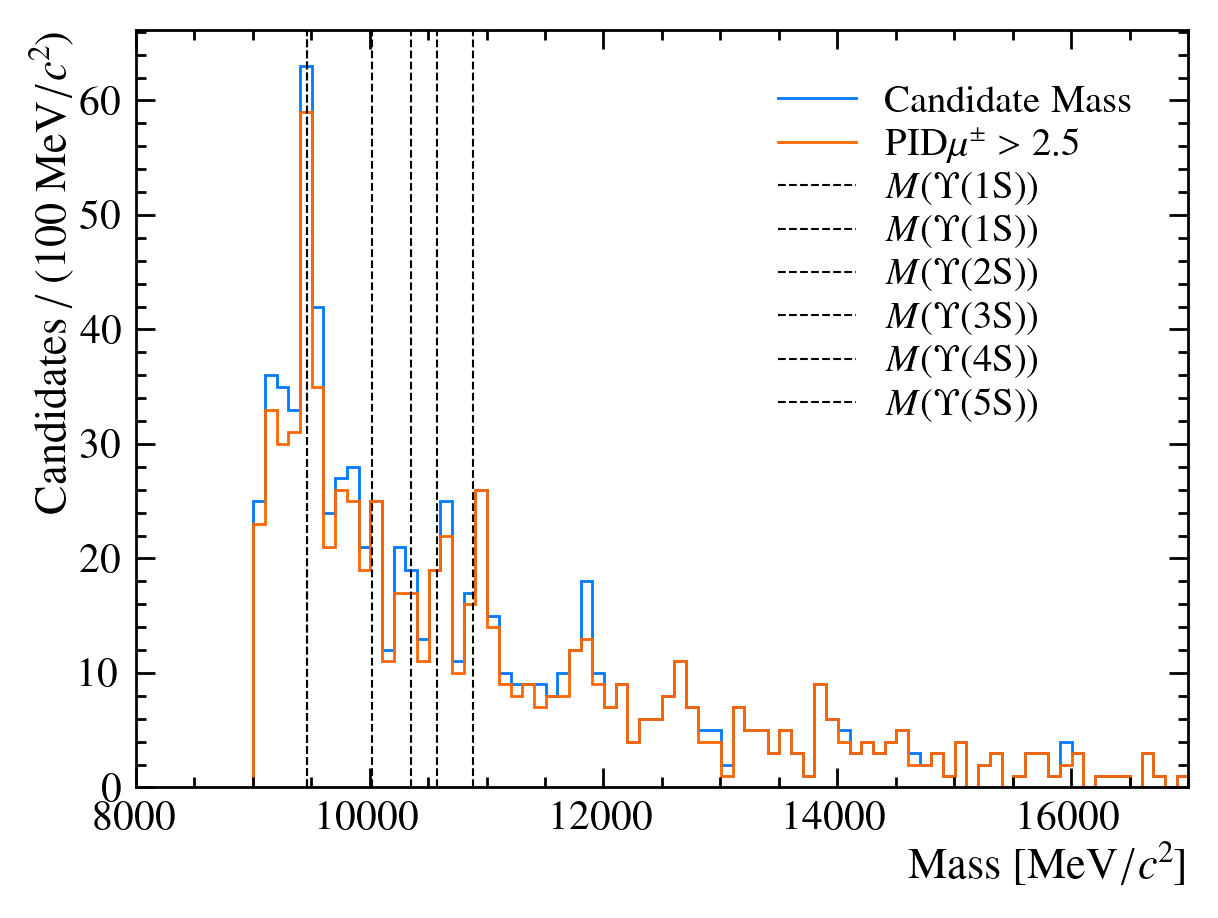

In [33]:
pidmu_df = df[df["muminus_PIDmu"] > 2.5]
pidmu_df = df[df["muplus_PIDmu"] > 2.5]


fig, ax = histogram_fig(
    [
        HistogramPlot(df["J_psi_1S_M"], "Candidate Mass", bins=100),
        HistogramPlot(pidmu_df["J_psi_1S_M"], r"PID$\mu^{\pm} > 2.5$", bins=100),
    ],
    False,
    xlim=[8000, 17_000],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass",
)
ax.axvline(
    constant.UPSILON_1S_MASS,
    color="k",
    linewidth=1.5,
    label=r"$M(\Upsilon\mathrm{(1S)})$",
    ls="--",
)
add_upsilon(ax, range(1,6))
ax.legend()